In [2]:
img_1 = "/home/tuong/Courses/CV/Chap3/data/flower1.jpg"

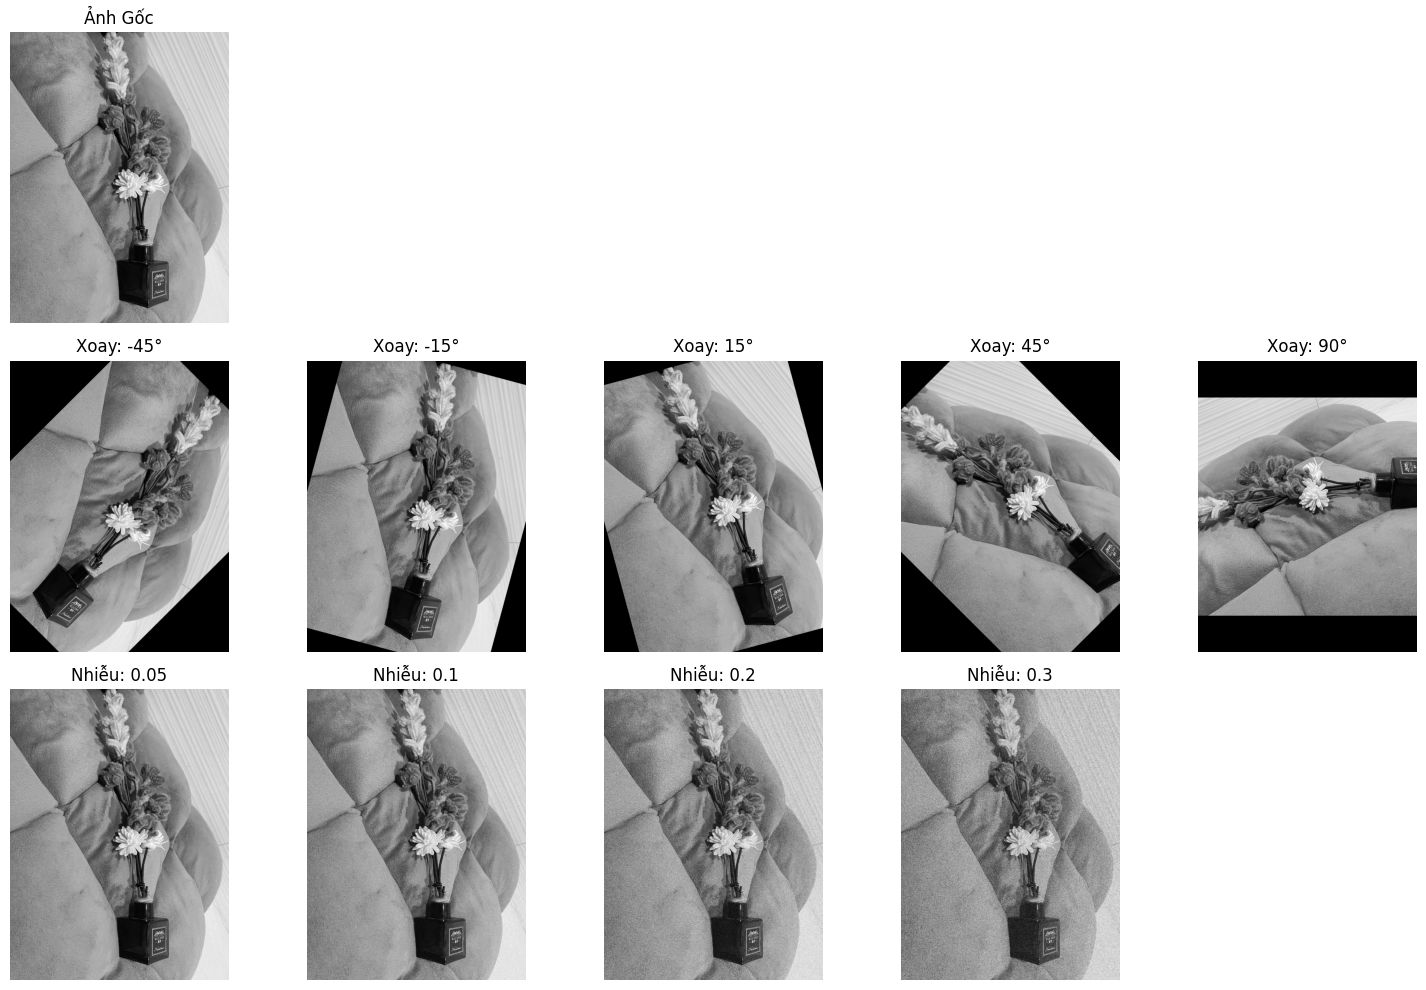

In [8]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(img_1,0)

# 1. Hàm xoay ảnh
def rotate_image(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    # Tạo ma trận xoay
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    # Thực hiện xoay ảnh
    rotated = cv2.warpAffine(image, M, (w, h))
    return rotated

# 2. Hàm thêm nhiễu (Gaussian Noise)
def add_noise(image, noise_level=0.05):
    # Tạo mảng nhiễu ngẫu nhiên với phân phối chuẩn
    noise = np.random.randn(*image.shape) * 255 * noise_level
    # Cộng nhiễu vào ảnh và giới hạn giá trị pixel từ 0 - 255
    noisy_image = np.clip(image + noise, 0, 255).astype(np.uint8)
    return noisy_image

# Khai báo các góc và mức độ nhiễu
angles = [-45, -15, 15, 45, 90]
noise_levels = [0.05, 0.1, 0.2, 0.3]

# --- HIỂN THỊ KẾT QUẢ ---
plt.figure(figsize=(15, 10))

# Hiển thị ảnh gốc
plt.subplot(3, 5, 1)
plt.imshow(img, cmap="gray")
plt.title('Ảnh Gốc')
plt.axis('off')

plot_idx = 6 # Chuyển xuống hàng thứ 2

# Hiển thị các ảnh xoay
for i, angle in enumerate(angles):
    rotated = rotate_image(img, angle)
    plt.subplot(3, 5, plot_idx + i)
    plt.imshow(rotated, "gray")
    plt.title(f'Xoay: {angle}°')
    plt.axis('off')
    
plot_idx = 11 # Chuyển xuống hàng thứ 3

# Hiển thị các ảnh có nhiễu
for i, noise in enumerate(noise_levels):
    noisy = add_noise(img, noise)
    plt.subplot(3, 5, plot_idx + i)
    plt.imshow(noisy, cmap= "gray")
    plt.title(f'Nhiễu: {noise}')
    plt.axis('off')
    
plt.tight_layout()
plt.show()

✅ Đã lưu thành công các ảnh vào thư mục: /home/tuong/Courses/CV/Chap3/augmented_images


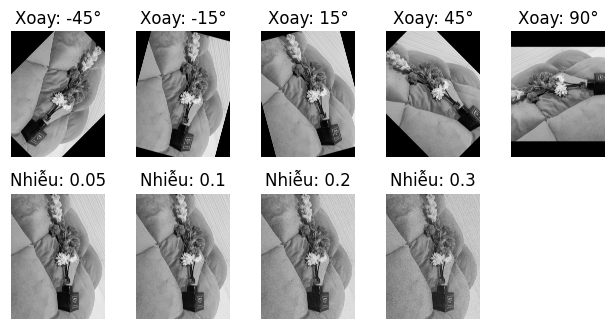

In [12]:
save_dir = "/home/tuong/Courses/CV/Chap3/augmented_images"
# Tạo thư mục nếu chưa tồn tại
os.makedirs(save_dir, exist_ok=True)

# Lấy tên file gốc (ví dụ: 'flower1')
base_name = os.path.splitext(os.path.basename(img_1))[0]

plot_idx = 6 # Chuyển xuống hàng thứ 2

# Xử lý, lưu và hiển thị ảnh xoay
for i, angle in enumerate(angles):
    # Tạo ảnh xoay
    rotated = rotate_image(img, angle) # Truyền BGR cho OpenCV để lưu chuẩn màu
    
    # Lưu ảnh (ảnh sẽ có dạng định dạng flower1_rotated_45.jpg)
    save_path = os.path.join(save_dir, f"{base_name}_rotated_{angle}.jpg")
    cv2.imwrite(save_path, rotated)
    
    # Hiển thị
    rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB) # Chuyển qua RGB cho Matplotlib
    plt.subplot(3, 5, plot_idx + i)
    plt.imshow(rotated_rgb)
    plt.title(f'Xoay: {angle}°')
    plt.axis('off')
    
plot_idx = 11 # Chuyển xuống hàng thứ 3

# Xử lý, lưu và hiển thị ảnh nhiễu
for i, noise in enumerate(noise_levels):
    # Tạo ảnh nhiễu
    noisy = add_noise(img, noise) # Truyền BGR cho OpenCV
    
    # Lưu ảnh
    save_path = os.path.join(save_dir, f"{base_name}_noise_{noise}.jpg")
    cv2.imwrite(save_path, noisy)
    
    # Hiển thị
    noisy_rgb = cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB) # Chuyển qua RGB cho Matplotlib
    plt.subplot(3, 5, plot_idx + i)
    plt.imshow(noisy_rgb)
    plt.title(f'Nhiễu: {noise}')
    plt.axis('off')
    
print(f"✅ Đã lưu thành công các ảnh vào thư mục: {save_dir}")

plt.tight_layout()
plt.show()